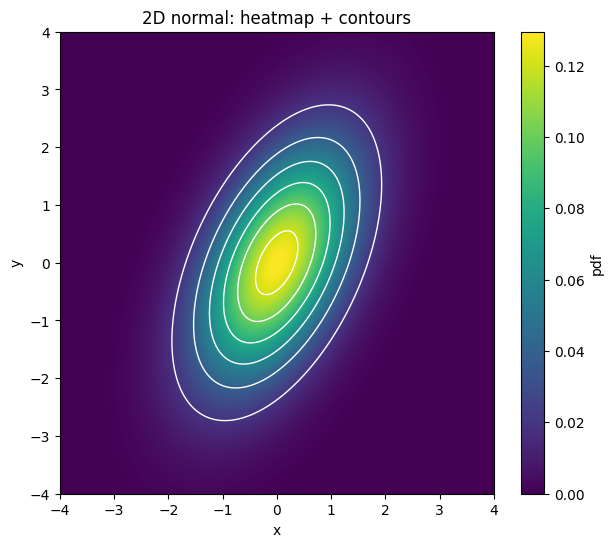

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# параметры распределения
mu = np.array([0.0, 0.0])               # средний вектор
Sigma = np.array([[1.0, 0.7],           # ковариационная матрица
                  [0.7, 2.0]])

rv = multivariate_normal(mean=mu, cov=Sigma)

# сетка по x,y
x = np.linspace(-4, 4, 300)
y = np.linspace(-4, 4, 300)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))

Z = rv.pdf(pos)

plt.figure(figsize=(7, 6))
plt.imshow(Z, extent=[x.min(), x.max(), y.min(), y.max()],
           origin="lower", cmap="viridis", aspect="auto")
plt.colorbar(label="pdf")

plt.contour(X, Y, Z, colors="white", linewidths=1)
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D normal: heatmap + contours")
plt.show()


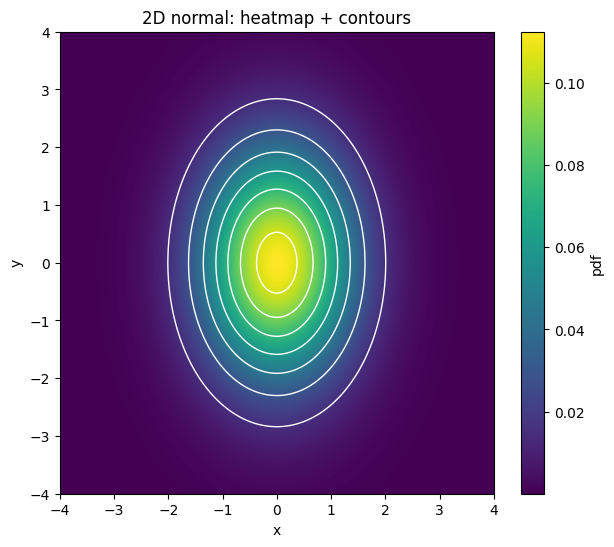

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# параметры распределения
mu = np.array([0.0, 0.0])               # средний вектор
Sigma = np.array([[1.0, 0.0],           # ковариационная матрица
                  [0.0, 2.0]])

rv = multivariate_normal(mean=mu, cov=Sigma)

# сетка по x,y
x = np.linspace(-4, 4, 300)
y = np.linspace(-4, 4, 300)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))

Z = rv.pdf(pos)

plt.figure(figsize=(7, 6))
plt.imshow(Z, extent=[x.min(), x.max(), y.min(), y.max()],
           origin="lower", cmap="viridis", aspect="auto")
plt.colorbar(label="pdf")

plt.contour(X, Y, Z, colors="white", linewidths=1)
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D normal: heatmap + contours")
plt.show()


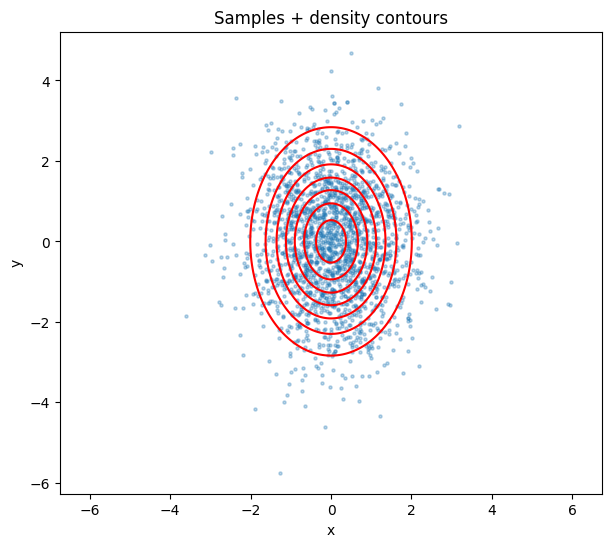

In [5]:
samples = rv.rvs(size=2000)

plt.figure(figsize=(7, 6))
plt.scatter(samples[:, 0], samples[:, 1], s=5, alpha=0.3)
plt.contour(X, Y, Z, colors="red")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Samples + density contours")
plt.axis("equal")
plt.show()


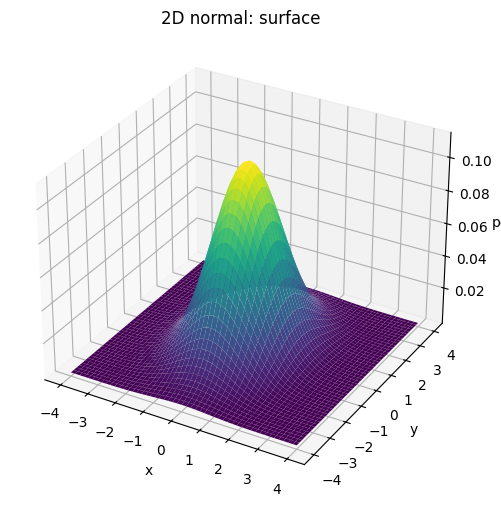

In [6]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z, cmap="viridis", linewidth=0, antialiased=True)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("pdf")
ax.set_title("2D normal: surface")
plt.show()

In [9]:
from space_bandits import LinearBandits

num_actions = 3
num_features = 2

linear_model = LinearBandits(num_actions, num_features, initial_pulls=100)

In [18]:
from space_bandits import NeuralBandits

num_actions = 3
num_features = 2
memory_size = 10000

neural_model = NeuralBandits(num_actions, num_features, initial_pulls=100, memory_size=memory_size, layer_sizes=[50, 12])

In [44]:
neural_model.bnn.

NeuralBanditModel(
  (layer 0): Linear(in_features=2, out_features=50, bias=True)
  (layer 1): Linear(in_features=50, out_features=12, bias=True)
  (loss): MSELoss()
)

In [16]:
import numpy as np
from catboost import CatBoostClassifier

# Данные: бинарная классификация
X = np.array([
    [0.1, 1.0],
    [0.2, 1.1],
    [0.3, 0.9],
    [0.8, 0.2],
    [0.9, 0.1],
    [1.0, 0.3],
    [0.4, 0.8],
    [0.7, 0.4],
], dtype=float)

y = np.array([0, 0, 0, 1, 1, 1, 0, 1], dtype=int)

model = CatBoostClassifier(
    iterations=1,   # одно дерево
    depth=4,
    loss_function="Logloss",
    verbose=False,
    random_seed=42,
)

model.fit(X, y)

In [9]:
# Индекс листа для каждого объекта
leaf_idx = model.calc_leaf_indexes(X)

In [10]:
leaf_idx

array([[1, 1],
       [1, 1],
       [1, 1],
       [0, 2],
       [0, 6],
       [0, 6],
       [1, 3],
       [1, 2]], dtype=uint32)

In [12]:
from sklearn.tree import DecisionTreeClassifier
model2 = DecisionTreeClassifier()
model2.fit(X,y)

DecisionTreeClassifier()

In [15]:
model2.predict_proba(X)

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.]])

In [17]:
# Индекс листа для каждого объекта
leaf_idx = model.calc_leaf_indexes(X)

# raw score = RawFormulaVal
raw_score = model.predict(X, prediction_type="RawFormulaVal")

# вероятности
proba = model.predict_proba(X)[:, 1]

print("leaf_idx shape:", leaf_idx.shape)
print("leaf_idx:\n", leaf_idx)
print()

print("raw_score:")
print(raw_score)
print()

print("probability of class 1:")
print(proba)
print()

# Проверка, что probability = sigmoid(raw_score)
sigmoid = 1 / (1 + np.exp(-raw_score))
print("sigmoid(raw_score):")
print(sigmoid)
print()

print("allclose(proba, sigmoid(raw_score)):", np.allclose(proba, sigmoid))

leaf_idx shape: (8, 1)
leaf_idx:
 [[1]
 [1]
 [1]
 [0]
 [0]
 [0]
 [1]
 [1]]

raw_score:
[-0.17647059 -0.17647059 -0.17647059  0.2         0.2         0.2
 -0.17647059 -0.17647059]

probability of class 1:
[0.45599649 0.45599649 0.45599649 0.549834   0.549834   0.549834
 0.45599649 0.45599649]

sigmoid(raw_score):
[0.45599649 0.45599649 0.45599649 0.549834   0.549834   0.549834
 0.45599649 0.45599649]

allclose(proba, sigmoid(raw_score)): True
